##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [6]:
!pip install -q keras-hub tensorflow pillow requests

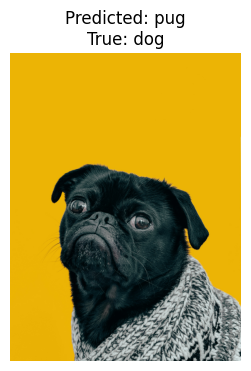

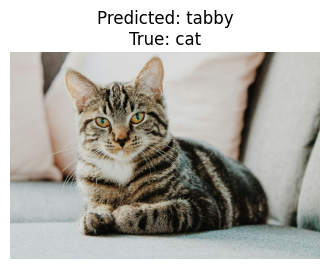

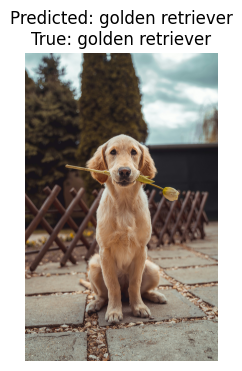

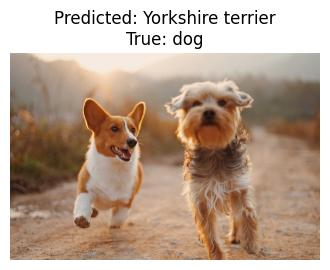

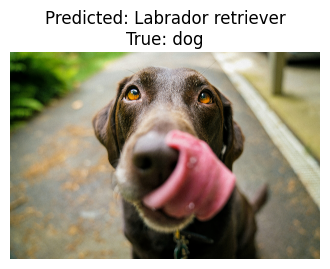


Results:
Image 1: Predicted = pug | True = dog | Correct = False
Image 2: Predicted = tabby | True = cat | Correct = False
Image 3: Predicted = golden retriever | True = golden retriever | Correct = True
Image 4: Predicted = Yorkshire terrier | True = dog | Correct = False
Image 5: Predicted = Labrador retriever | True = dog | Correct = False


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
import keras_hub

# Required components for the assignment
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)

model = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    preprocessor=None
)

# ImageNet class names
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = requests.get(labels_url).text.strip().split("\n")

# 5 reliable images
image_urls = [
    "https://images.unsplash.com/photo-1517849845537-4d257902454a",  # dog
    "https://images.unsplash.com/photo-1518791841217-8f162f1e1131",  # cat
    "https://images.unsplash.com/photo-1552053831-71594a27632d",     # golden retriever
    "https://images.unsplash.com/photo-1548199973-03cce0bbc87b",     # dog
    "https://images.unsplash.com/photo-1518717758536-85ae29035b6d"   # dog
]

true_labels = [
    "dog",
    "cat",
    "golden retriever",
    "dog",
    "dog"
]

headers = {"User-Agent": "Mozilla/5.0"}

images = []
valid_true = []

# Download images safely
for url, label in zip(image_urls, true_labels):
    try:
        r = requests.get(url, headers=headers, timeout=30)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert("RGB")
        images.append(np.array(img))
        valid_true.append(label)
    except Exception as e:
        print("Skipping image:", e)

images = np.array(images, dtype=object)

# Preprocess images
processed_images = np.stack([preprocessor(img) for img in images], axis=0)

# Predict
predictions = model.predict(processed_images, verbose=0)
predicted_classes = np.argmax(predictions, axis=-1)
predicted_labels = [labels[i] for i in predicted_classes]

# Show predictions
for i, img in enumerate(images):
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_labels[i]}\nTrue: {valid_true[i]}")
    plt.show()

# Print results table
print("\nResults:")
for i in range(len(images)):
    correct = valid_true[i].lower() in predicted_labels[i].lower()
    print(f"Image {i+1}: Predicted = {predicted_labels[i]} | True = {valid_true[i]} | Correct = {correct}")

### Record Your Results

Fill the table below based on your results:

| Image File   | Predicted Label | True Label (What you searched) | Correct? (Yes/No) |
| ------------ | --------------- | ------------------------------ | ----------------- |
|            1  | pug          |     dog                           | No            |
|            2  | tabby          |     cat                           | No            |
|            3  | golden retriever          |      golden retriever                         | Yes            |
|             4 | Yorkshire terrier          |     dog                           | No            |
|             5 | Labrador retriever          |        dog                        | No            |
